# **02 - Exploratory Data Analysis**

## Objectives

- Load and inspect the cleaned Online Retail Transaction dataset.
- Explore overall revenue and sales performance.
- Analyse revenue and sales volume over time.
- Investigate product and customer purchasing patterns.
- Compare geographic performance across countries.
- Explore relevant distributions and relationships within the data.
- Identify key insights that can support further visualisation and machine learning analysis.

## Inputs

- Cleaned Online Retail Transaction dataset produced during the ETL process and stored in the `outputs` folder.

## Outputs

- Exploratory analysis of the Online Retail Transaction dataset.
- Key findings and visualisations relating to revenue, sales volume, customers, products and geographic performance.
- Insights to support subsequent stages of the project.

## Additional Comments

- Analysis will be exploratory, with findings and interpretations documented throughout the notebook.

---

# Change working directory

In [1]:
import os

current_dir = os.getcwd()
print("Current directory:", current_dir)

if os.path.basename(current_dir) == "jupyter_notebooks":
    os.chdir(os.path.dirname(current_dir))
elif os.path.basename(current_dir) == "vscode-projects":
    os.chdir("Online Retail Transaction Analysis")

current_dir = os.getcwd()
print("Working directory set to:", current_dir)

Current directory: /Users/sahraosman/Documents/vscode-projects/Online Retail Transaction Analysis/jupyter_notebooks
Working directory set to: /Users/sahraosman/Documents/vscode-projects/Online Retail Transaction Analysis


---

# Section 1 -  Import libraries

Here I will be importing the libraries that I will be using in this notebook.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns


---

# Section 2 - Load the dataset

Here I will load the cleaned Online Retail Transaction dataset that was produced during the ETL process.

In [3]:
df = pd.read_csv("outputs/Online_Retail_Cleaned.csv")

/var/folders/cx/w0ydrn213c14xglf6wmp_2l00000gn/T/ipykernel_77303/3308739013.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("outputs/Online_Retail_Cleaned.csv")


In [4]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID       int64
Country         object
Revenue        float64
dtype: object

The initial import produced a mixed data type warning for `InvoiceNo`. Inspection of the imported data types also showed that `InvoiceDate` had been loaded as an object rather than a datetime.

In [5]:
df["InvoiceNo"].apply(type).value_counts()

InvoiceNo
<class 'int'>    459342
<class 'str'>     65536
Name: count, dtype: int64

Further inspection showed that `InvoiceNo` contained both integer and string values. Since invoice numbers are identifiers rather than numerical measures, the column will be explicitly loaded as a string. `InvoiceDate` will also be parsed as a datetime to support time-based analysis.

In [6]:
df = pd.read_csv(
    "outputs/Online_Retail_Cleaned.csv",
    dtype={"InvoiceNo": str},
    parse_dates=["InvoiceDate"],
)

In [7]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
Revenue               float64
dtype: object

In [8]:
df["InvoiceNo"].apply(type).value_counts()

InvoiceNo
<class 'str'>    524878
Name: count, dtype: int64

The corrected import confirms that all `InvoiceNo` values are now consistently loaded as strings and `InvoiceDate` has been successfully parsed as a datetime. The cleaned dataset is now loaded with appropriate data types for exploratory analysis.

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [10]:
print("Number of rows: ", df.shape[0])

Number of rows:  524878


In [11]:
print("Number of columns: ", df.shape[1])

Number of columns:  9


The dataset contains 524,878 records and 9 columns, matching the final dataset produced during the ETL process. An initial preview also confirms that the cleaned data and engineered `Revenue` feature have loaded successfully and are ready for exploratory analysis.

---

# Section 3 - Overall Business Performance

In this section, I will explore the overall business performance of the Online Retail Transaction dataset. This will include an analysis of total revenue, sales volume and other key metrics to provide an overview of the business's performance.

In [12]:
total_revenue = df["Revenue"].sum()
print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 10,642,110.80


The total revenue generated across the cleaned transaction records is 10,642,110.80. This provides an overall measure of the revenue represented within the dataset and will be explored further across time periods, products, customers and countries.

In [13]:
total_sales_volume = df["Quantity"].sum()
print(f"Total Sales Volume: {total_sales_volume:,}")

Total Sales Volume: 5,572,420


A total of 5,572,420 units were sold across the cleaned transaction records. This represents the overall sales volume within the dataset and can later be explored across time periods, products and countries.

In [14]:
total_transactions = df["InvoiceNo"].nunique()
unique_customers = df["CustomerID"].nunique()

print(f"Total Transactions: {total_transactions:,}")
print(f"Unique Customers: {unique_customers:,}")

Total Transactions: 19,960
Unique Customers: 4,338


The dataset contains 19,960 unique transactions across 4,338 unique customers. The difference between these figures indicates that customers can make multiple transactions, which will be investigated further during the customer purchasing behaviour analysis.

In [15]:
average_transaction = total_revenue / total_transactions

print(f"Average Transaction Value: {average_transaction:,.2f}")

Average Transaction Value: 533.17


The average transaction value across the dataset is 533.17. This represents the mean revenue generated per unique transaction. However, the average may be influenced by higher-value transactions, so the distribution of transaction values will be explored further during the analysis.

To provide a clear overview of the key business performance metrics calculated above, the results are summarised in a single DataFrame.

In [16]:
business_summary = pd.DataFrame(
    {
        "Metric": [
            "Total Revenue",
            "Total Sales Volume",
            "Total Transactions",
            "Unique Customers",
            "Average Transaction Value",
        ],
        "Value": [
            total_revenue,
            total_sales_volume,
            total_transactions,
            unique_customers,
            average_transaction,
        ],
    }
)
business_summary

,Metric,Value
0,Total Revenue,1.064211e+07
1,Total Sales Volume,5.572420e+06
2,Total Transactions,1.996000e+04
3,Unique Customers,4.338000e+03
4,Average Transaction Value,5.331719e+02


Overall, the dataset contains transactions generating a total revenue of 10,642,110.80 from 5,572,420 units sold across 19,960 transactions and 4,338 unique customers. The average transaction value is 533.17. These metrics provide a baseline for further analysis of how performance varies over time, across products, customers and geographic regions.

---

# Section 4 - Revenue and Sales Volume Over Time

In this section, I will analyse how revenue and sales volume change over time. The transaction date range will first be examined to understand the period covered by the dataset. Monthly revenue and sales volume will then be analysed to identify trends, fluctuations and periods of higher or lower sales activity.

In [17]:
df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [18]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

The dataset covers transactions from 1 December 2010 to 9 December 2011. This provides approximately one year of transaction data; however, December 2011 contains only partial-month data. This will be considered when interpreting monthly revenue and sales volume trends.

In [19]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [20]:
df[["InvoiceDate", "YearMonth"]].head()

,InvoiceDate,YearMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


A `YearMonth` feature was created from `InvoiceDate` to support monthly trend analysis. Including both the year and month ensures that transactions from December 2010 and December 2011 are treated as separate periods.

In [21]:
df.groupby("YearMonth")["Revenue"].sum().reset_index()

,YearMonth,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


In [ ]:
monthly_performance = (
    df.groupby("YearMonth")[["Revenue", "Quantity"]].sum().reset_index()
)
monthly_performance

,YearMonth,Revenue,Quantity
0,2010-12,821452.730,358019
1,2011-01,689811.610,387099
2,2011-02,522545.560,282934
3,2011-03,716215.260,376599
4,2011-04,536968.491,307953
5,2011-05,769296.610,395001
6,2011-06,760547.010,388511
7,2011-07,718076.121,399693
8,2011-08,757841.380,421020
9,2011-09,1056435.192,569573


In [23]:
monthly_performance.dtypes

YearMonth    period[M]
Revenue        float64
Quantity         int64
dtype: object

The `YearMonth` column is stored as a pandas Period data type. To ensure compatibility with Seaborn when plotting the monthly trends, the column will be converted to a string for use as the x-axis labels.

In [24]:
monthly_performance["YearMonth"] = monthly_performance["YearMonth"].astype(str)

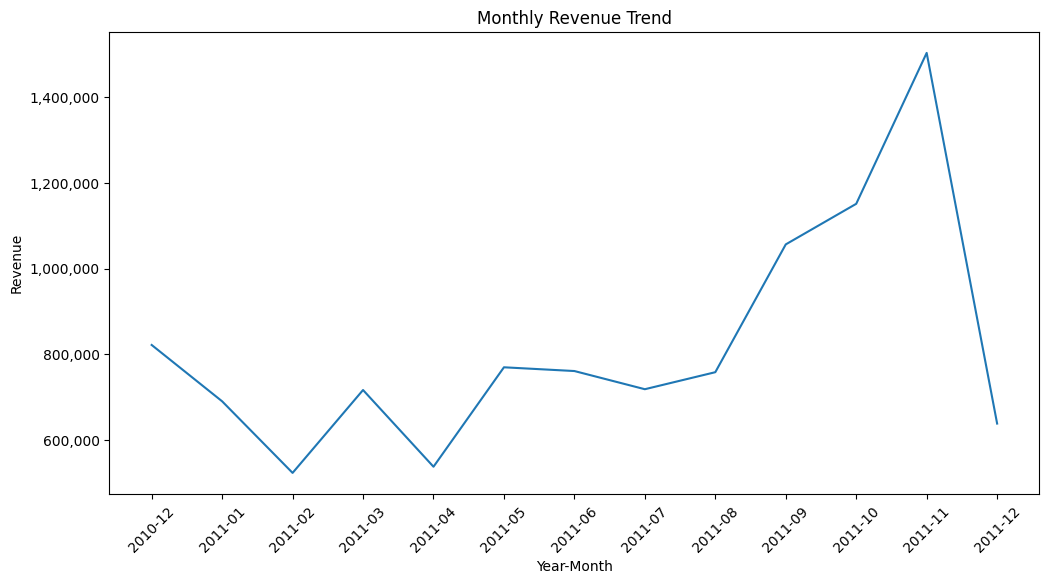

In [25]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_performance, x="YearMonth", y="Revenue")
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
revenue_formatter = FuncFormatter(lambda x, _: f"{x:,.0f}")
plt.gca().yaxis.set_major_formatter(revenue_formatter)
plt.show()

Monthly revenue fluctuates throughout the first half of the period, declining from December 2010 to February 2011 before recovering in March. Revenue falls again in April, followed by a stronger increase in May and relatively smaller fluctuations through to August.

A more substantial increase is visible from August onwards, with revenue rising sharply in September and continuing to increase through October before reaching its highest level in November 2011. This suggests that the strongest revenue performance within the complete monthly periods occurred towards the later months of 2011.

Revenue appears to fall substantially in December 2011; however, this should not be interpreted as a genuine decline in performance because the dataset only contains transactions up to 9 December. December 2011 is therefore an incomplete month and is not directly comparable with the complete monthly periods.

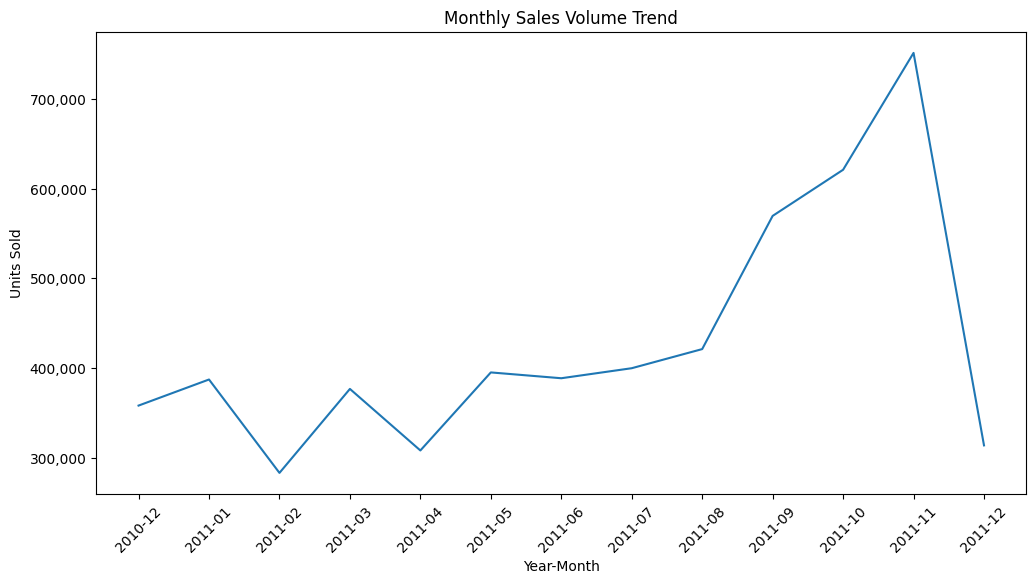

In [26]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_performance, x="YearMonth", y="Quantity")
plt.title("Monthly Sales Volume Trend")
plt.xlabel("Year-Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
quantity_formatter = FuncFormatter(lambda x, _: f"{x:,.0f}")
plt.gca().yaxis.set_major_formatter(quantity_formatter)
plt.show()

Monthly sales volume broadly follows a similar pattern to revenue, although the two measures do not move together in every period. Sales volume increases from December 2010 to January 2011 despite revenue decreasing over the same period. This is followed by a decline in February, an increase in March and another decline in April.

Sales volume recovers in May and remains relatively stable with smaller fluctuations through to August. From August onwards, sales activity increases substantially, with a sharp rise in September followed by further growth through October and November. November 2011 records the highest sales volume within the dataset.

The overall similarity between the revenue and sales volume trends suggests that higher quantities sold are generally associated with higher monthly revenue. However, periods such as December 2010 to January 2011 show that the relationship is not exact, suggesting that factors such as product prices and the mix of products purchased may also influence monthly revenue. The apparent decline in December 2011 should again be interpreted cautiously because the dataset only contains transactions up to 9 December.